#Code eager softmax in Pytorch, Triton


In [ ]:
!nvidia-smi

Mon Mar 16 09:22:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install torch torchvision torchaudio
!pip install triton

In [ ]:
import torch

import triton
import triton.language as tl
import torch.nn.functional as F

In [ ]:
def naive_softmax(x: torch.Tensor) -> torch.Tensor:
  """ eager mode softmax """
  x_max = x.max(dim=1)[0]
  safe_x = x-x_max[:, None]
  numerator = torch.exp(safe_x)
  denominator = numerator.sum(dim=1)
  sm_out = numerator/denominator[:,None]
  return sm_out


In [ ]:
#making a triton kernel
@triton.jit
def __softmax_fwd_kernel(
    output_ptr, stride_output_row,
    input_ptr, stride_input_row,
    num_cols,
    BLOCK_SIZE: tl.constexpr,
):
  #setup the ptrs
  row_index = tl.program_id(0)

  row_start_ptr = input_ptr + (row_index * stride_input_row)
  col_offsets = tl.arange(0, BLOCK_SIZE)
  input_pointers = row_start_ptr + col_offsets

  row_mask = col_offsets < num_cols

  #move from hbm to sram
  row = tl.load(input_pointers, mask=row_mask, other=-float('inf'))

  #softmax
  row_max = tl.max(row, axis=0)
  safe_row = row - row_max
  numerator = tl.exp(safe_row)
  denominator = tl.sum(numerator, axis=0)
  sm_out = numerator / denominator

  #write back to hbm
  output_row_ptr = output_ptr + (row_index * stride_output_row)
  output_pointers = output_row_ptr + col_offsets
  tl.store(output_pointers, sm_out, mask=row_mask)


def softmax(x: torch.Tensor) -> torch.Tensor:
  """ triton softmax """
  rows, cols = x.shape
  assert x.dim() == 2, f"only accepts 2D tensors for now"
  block_size = triton.next_power_of_2(cols) #ffinds space which is number just greater than cols size
  num_warps = 4 #32 threads
  if block_size > 2047: # 2048
    num_warps = 8
  if block_size > 4095: #4096
    num_warps = 16

  grid = (rows,)

  #allocate our output buffer
  sm_out = torch.empty_like(x)

  __softmax_fwd_kernel[grid](
      sm_out,
      sm_out.stride(0),
      x,
      x.stride(0),
      cols,
      BLOCK_SIZE = block_size,
      num_warps = num_warps
  )

  return sm_out

In [ ]:
sample = torch.tensor([[1,2,3,4,5], [5,4,3,2,1]], dtype=torch.float32, device='cuda')
ref_out = F.softmax(sample, dim=1)
ref_out

tensor([[0.0117, 0.0317, 0.0861, 0.2341, 0.6364],
        [0.6364, 0.2341, 0.0861, 0.0317, 0.0117]], device='cuda:0')

In [ ]:
eager_out = naive_softmax(sample)
eager_out

tensor([[0.0117, 0.0317, 0.0861, 0.2341, 0.6364],
        [0.6364, 0.2341, 0.0861, 0.0317, 0.0117]], device='cuda:0')

In [ ]:
triton_output = softmax(sample)
print(triton_output.device)
print(f"{triton_output}")


tensor([[0.0117, 0.0317, 0.0861, 0.2341, 0.6364],
        [0.6364, 0.2341, 0.0861, 0.0317, 0.0117]], device='cuda:0')


In [ ]:
import time

# make it big enough to see GPU usage
big = torch.randn(100000, 4096, dtype=torch.float32, device='cuda')  # adjust if OOM
# compile/run once to avoid including compilation time
_ = softmax(big[:2, :1024])  # warm-up (small slice to trigger compile)

torch.cuda.synchronize()
t0 = time.time()
out = softmax(big)
torch.cuda.synchronize()
t1 = time.time()
print(f"Triton softmax time: {t1-t0:.4f}s")

# compare to PyTorch softmax (on same input) if you want:
torch.cuda.synchronize()
t0 = time.time()
out_torch = torch.softmax(big, dim=1)
torch.cuda.synchronize()
t1 = time.time()
print(f" PyTorch softmax time: {t1-t0:.4f}s")

# correctness quick-check (sample few rows due to cost)
print("allclose (subset):", torch.allclose(out[:4,:], out_torch[:4,:], atol=1e-5))

Triton softmax time: 0.0139s
 PyTorch softmax time: 0.0223s
allclose (subset): True


In [ ]:
!nvidia-smi

Mon Mar 16 09:38:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P0             29W /   70W |    5353MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Shapes: ['256x256', '256x512', '256x1024', '512x256', '512x512', '512x1024', '1024x256', '1024x512', '1024x1024', '1024x2048', '2048x256', '2048x512', '2048x1024', '2048x2048', '4096x256', '4096x512', '4096x1024', '4096x2048', '8192x256', '8192x512', '8192x1024', '8192x2048', '16384x256', '16384x512', '16384x1024', '32768x256', '32768x512', '65536x256', '65536x512', '100000x4096']
Triton times: [0.0003616809844970703, 6.508827209472656e-05, 6.0558319091796875e-05, 5.841255187988281e-05, 6.198883056640625e-05, 6.079673767089844e-05, 6.0558319091796875e-05, 8.320808410644531e-05, 8.130073547363281e-05, 0.00012254714965820312, 9.465217590332031e-05, 8.20159912109375e-05, 0.0001475811004638672, 0.0001933574676513672, 9.72747802734375e-05, 0.00012040138244628906, 0.00019025802612304688, 0.0003330707550048828, 0.00016450881958007812, 0.0001838207244873047, 0.00033283233642578125, 0.0006122589111328125, 0.0002434253692626953, 0.0003237724304199219, 0.0006151199340820312, 0.0004305839538574219

<Figure size 640x480 with 0 Axes>

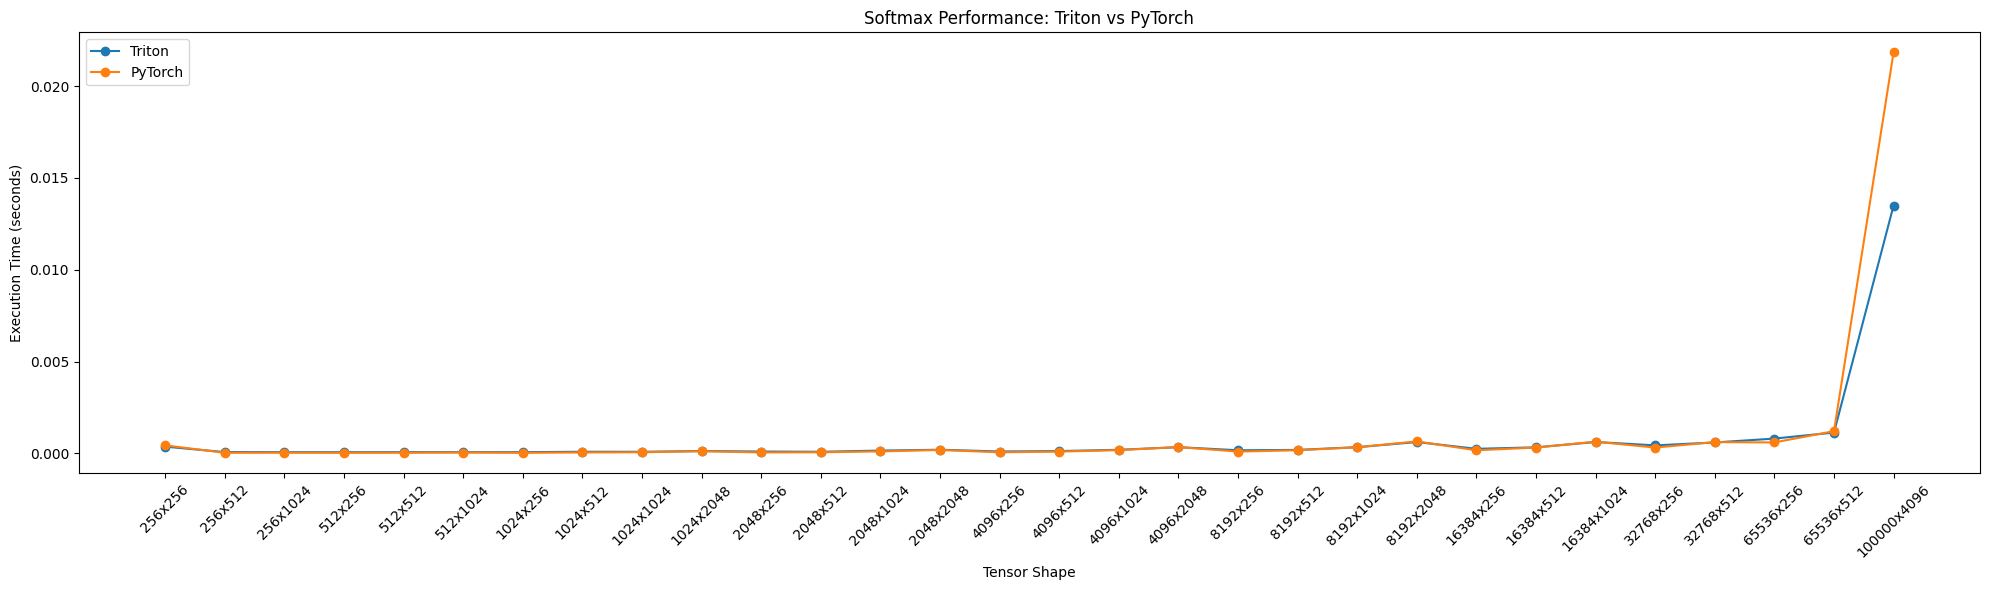

In [ ]:
import torch
import time
import matplotlib.pyplot as plt

# sizes to test (rows, cols)
test_shapes = [
    (256, 256),
    (256, 512),
    (256, 1024),

    (512, 256),
    (512, 512),
    (512, 1024),

    (1024, 256),
    (1024, 512),
    (1024, 1024),
    (1024, 2048),

    (2048, 256),
    (2048, 512),
    (2048, 1024),
    (2048, 2048),

    (4096, 256),
    (4096, 512),
    (4096, 1024),
    (4096, 2048),

    (8192, 256),
    (8192, 512),
    (8192, 1024),
    (8192, 2048),

    (16384, 256),
    (16384, 512),
    (16384, 1024),

    (32768, 256),
    (32768, 512),

    (65536, 256),
    (65536, 512),

    (100000, 4096)
]

triton_times = []
torch_times = []
labels = []

for rows, cols in test_shapes:

    x = torch.randn(rows, cols, device="cuda", dtype=torch.float32)

    # warmup
    _ = softmax(x[:2, :min(cols,1024)])
    _ = torch.softmax(x, dim=1)

    # Triton timing
    torch.cuda.synchronize()
    t0 = time.time()
    out_triton = softmax(x)
    torch.cuda.synchronize()
    t1 = time.time()

    triton_times.append(t1 - t0)

    # PyTorch timing
    torch.cuda.synchronize()
    t0 = time.time()
    out_torch = torch.softmax(x, dim=1)
    torch.cuda.synchronize()
    t1 = time.time()

    torch_times.append(t1 - t0)

    labels.append(f"{rows}x{cols}")

    # correctness check
    assert torch.allclose(out_triton[:4], out_torch[:4], atol=1e-5)

# print collected values
print("Shapes:", labels)
print("Triton times:", triton_times)
print("PyTorch times:", torch_times)

# plotting
plt.figure()

plt.figure(figsize=(20,6))
plt.plot(labels, triton_times, marker='o', label="Triton")
plt.plot(labels, torch_times, marker='o', label="PyTorch")

plt.xlabel("Tensor Shape")
plt.ylabel("Execution Time (seconds)")
plt.title("Softmax Performance: Triton vs PyTorch")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()